In [10]:
# Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# df de equipos y ordenes
data_equipos = pd.read_excel('info_TEC_limpio.xlsx', sheet_name="Equipos")
data_ordenes = pd.read_excel('info_TEC_limpio.xlsx', sheet_name="Ordenes de trabajo")
data_refacciones = pd.read_excel('info_TEC_limpio.xlsx', sheet_name="Refacciones")

data_refacciones['Order'] = data_refacciones['Order'].astype(str)
data_ordenes['Order'] = data_ordenes['Order'].astype(str)

In [12]:
exactos = ['WM01', 'WM02']

# Filtramos: que esté en la lista de exactos O que contenga 'WPM2'
data_ordenes_filtrada = data_ordenes[
    (data_ordenes['Order Type'].isin(exactos) | data_ordenes['Order Type'].str.contains('WPM2', na=False)) & 
    (data_ordenes['Order Type'] != 0) & 
    (data_ordenes['Order Type'] != '0')
]

print(f"Filas originales: {len(data_ordenes)}")
print(f"Filas filtradas: {len(data_ordenes_filtrada)}")
print(f"Diferencia: {len(data_ordenes) - len(data_ordenes_filtrada)}")

Filas originales: 28908
Filas filtradas: 28908
Diferencia: 0


In [13]:
print("Columnas en Equipos:", data_equipos.columns.tolist())
print("Columnas en Ordenes:", data_ordenes_filtrada.columns.tolist())
print ("Columnas en Refacciones:", data_refacciones.columns.tolist())

Columnas en Equipos: ['EQUIPO', 'MARCA', 'MODELO', 'TIPO']
Columnas en Ordenes: ['Order', 'Main WorkCtr', 'Description', 'Functional Loc.', 'Created On', 'Entered By', 'Changed On', 'Changed By', 'Total act.costs', 'Cost Center', 'User status', 'Order Type', 'Equipment', 'MaintPlant', 'Description.1', 'Plant', 'Revision', 'Work center']
Columnas en Refacciones: ['Order', 'Description', 'G/L Account', 'Amount in LC', 'Plant', 'Purchase order', 'Material Doc.', 'Document Date', 'Material', 'Quantity', 'Currency', 'Posting Date', 'Quantity in UnE', 'Vendor']


In [14]:
print("Columnas en Equipos:", data_equipos.columns.tolist())
print("Columnas en Ordenes:", data_ordenes_filtrada.columns.tolist())
print ("Columnas en Refacciones:", data_refacciones.columns.tolist())

Columnas en Equipos: ['EQUIPO', 'MARCA', 'MODELO', 'TIPO']
Columnas en Ordenes: ['Order', 'Main WorkCtr', 'Description', 'Functional Loc.', 'Created On', 'Entered By', 'Changed On', 'Changed By', 'Total act.costs', 'Cost Center', 'User status', 'Order Type', 'Equipment', 'MaintPlant', 'Description.1', 'Plant', 'Revision', 'Work center']
Columnas en Refacciones: ['Order', 'Description', 'G/L Account', 'Amount in LC', 'Plant', 'Purchase order', 'Material Doc.', 'Document Date', 'Material', 'Quantity', 'Currency', 'Posting Date', 'Quantity in UnE', 'Vendor']


In [15]:
#Tiempo promedio por año y por tipo().
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'], errors='coerce')
data_ordenes['Changed On'] = pd.to_datetime(data_ordenes['Changed On'], errors='coerce')

data_ordenes['Duracion_dias'] = (
    data_ordenes['Changed On'] - data_ordenes['Created On']
).dt.days


data_ordenes['AÑO'] = data_ordenes['Created On'].dt.year

data_ordenes_filtrada = data_ordenes[
    (data_ordenes['AÑO'] != 2005) & (data_ordenes['AÑO'] != 2006)
]

ordenes_con_tipo = pd.merge(
    data_ordenes_filtrada,
    data_equipos[['EQUIPO', 'TIPO']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)

tiempo_promedio = (
    ordenes_con_tipo
    .groupby(['AÑO', 'TIPO'])['Duracion_dias']
    .mean()
    .reset_index()
)

print(tiempo_promedio)

     AÑO       TIPO  Duracion_dias
0   2020  AMERICANO     620.124836
1   2021  AMERICANO     250.654149
2   2021      CHINO     262.000000
3   2022  AMERICANO     227.500000
4   2022      CHINO     262.317073
5   2022    EUROPEO     295.081633
6   2023  AMERICANO     180.236688
7   2023      CHINO     201.701711
8   2023    EUROPEO     247.567901
9   2024  AMERICANO     119.501585
10  2024      CHINO     122.332312
11  2024    EUROPEO     125.574279
12  2025  AMERICANO      99.434192
13  2025      CHINO     103.294911
14  2025    EUROPEO     102.816602
15  2026  AMERICANO      20.796943
16  2026      CHINO      18.142857
17  2026    EUROPEO      24.955224


In [16]:
#Tiempo promedio por modelo (eliminado modelos del 2005 y 2006).
data_ordenes_filtrada['Created On'] = pd.to_datetime(data_ordenes_filtrada['Created On'], errors='coerce')
data_ordenes_filtrada['Changed On'] = pd.to_datetime(data_ordenes_filtrada['Changed On'], errors='coerce')

data_ordenes_filtrada['Duracion_dias'] = (
    data_ordenes_filtrada['Changed On'] - data_ordenes['Created On']
).dt.days


data_ordenes_filtrada_año = data_ordenes[
    (data_ordenes['AÑO'] != 2005) & (data_ordenes['AÑO'] != 2006)
]

ordenes_con_tipo = pd.merge(
   data_ordenes_filtrada_año,
    data_equipos[['EQUIPO', 'MARCA']],
    left_on='Equipment',
    right_on='EQUIPO',
    how='left'
)

tiempo_promedio = (
    ordenes_con_tipo
    .groupby(['AÑO', 'MARCA'])['Duracion_dias']
    .mean()
    .reset_index()
)

print(tiempo_promedio)

     AÑO          MARCA  Duracion_dias
0   2020  INTERNATIONAL     591.007812
1   2020       KENWORTH     620.238064
2   2020   MACK GRANITE     634.157996
3   2021          FOTON     262.000000
4   2021  INTERNATIONAL     222.596774
5   2021       KENWORTH     246.728211
6   2021   MACK GRANITE     271.603774
7   2021      SINOTRUCK     262.000000
8   2022          FOTON     281.166667
9   2022  INTERNATIONAL     218.380503
10  2022       KENWORTH     222.514945
11  2022   MACK GRANITE     242.873606
12  2022         SCANIA     295.081633
13  2022      SINOTRUCK     257.015625
14  2023          FOTON     231.436620
15  2023  INTERNATIONAL     177.148825
16  2023       KENWORTH     176.038928
17  2023   MACK GRANITE     188.717095
18  2023         SCANIA     247.567901
19  2023      SINOTRUCK     195.455621
20  2024          FOTON     122.463576
21  2024  INTERNATIONAL     124.173295
22  2024       KENWORTH     116.847677
23  2024   MACK GRANITE     123.204451
24  2024         SCANIA  

In [19]:
# =============================================================================
# ESTRATEGIA DE ABASTECIMIENTO GCC - MODELO GLOBAL DE RIESGO
# =============================================================================

# --- 1. CONFIGURACIÓN DE PARÁMETROS ---
COSTO_PARO_HORA = 489.00      
HORAS_OPERATIVAS_DIA = 12     
LT_CHINA = 15                 # Lead Time para marcas chinas
LT_AMERICANO = 3              # Lead Time para marcas americanas

# --- 2. PROCESAMIENTO DE FECHAS Y FILTRO (0-384 DÍAS) ---
data_ordenes['Created On'] = pd.to_datetime(data_ordenes['Created On'])
data_ordenes['Changed On'] = pd.to_datetime(data_ordenes['Changed On'])
data_ordenes['Diferencia_Dias'] = (data_ordenes['Changed On'] - data_ordenes['Created On']).dt.days

# Filtro: eliminamos registros mayores a 384 días o negativos
df_ordenes_filtrado = data_ordenes[
    (data_ordenes['Diferencia_Dias'] >= 0) & 
    (data_ordenes['Diferencia_Dias'] <= 384)
].copy()

# --- 3. CONSOLIDACIÓN DE DATOS ---
# Unimos refacciones con las órdenes filtradas
df_consolidado = pd.merge(
    data_refacciones, 
    df_ordenes_filtrado[['Order', 'Equipment', 'Diferencia_Dias']], 
    on='Order', 
    how='inner' 
)

# Traemos el tipo de equipo (CHINO / AMERICANO) desde el catálogo de equipos
df_consolidado = pd.merge(
    df_consolidado, 
    data_equipos[['EQUIPO', 'TIPO', 'MARCA']],  # ✅ agrega MARCA aquí
    left_on='Equipment', 
    right_on='EQUIPO', 
    how='left'
)

# --- 4. AGRUPACIÓN POR MATERIAL (CATÁLOGO GLOBAL) ---
analisis_refacciones = df_consolidado.groupby(['Material', 'Description']).agg({
    'Order': 'count',
    'Quantity': 'sum',
    'Amount in LC': 'mean',
    'Diferencia_Dias': 'mean', 
    'TIPO': lambda x: x.mode()[0] if not x.mode().empty else 'AMERICANO'
}).rename(columns={
    'Order': 'Movimientos', 
    'Amount in LC': 'Costo_Unitario',
    'Diferencia_Dias': 'Dias_Paro_Promedio'
}).reset_index()

# --- 5. LÓGICA DE CRITICIDAD Y PÉRDIDA ATERRIZADA ---
def calcular_estrategia_global(row):
    demanda_diaria = row['Quantity'] / 365
    
    # Identificación de piezas críticas para la movilidad
    palabras_vitales = ['EJE', 'BOMBA', 'MOTOR', 'TRANSMISION', 'FRENO', 'HIDRAULICO', 'DIFERENCIAL']
    es_vital = any(x in row['Description'].upper() for x in palabras_vitales)
    factor_impacto = 1.0 if es_vital else 0.15 
    
    # Parámetros diferenciados por origen
    if row['TIPO'] == 'CHINO':
        minimo = np.ceil(demanda_diaria * LT_CHINA * 1.5)
        meta = np.ceil(demanda_diaria * 90) 
        estatus = "CHINO"
    else:
        minimo = np.ceil(demanda_diaria * LT_AMERICANO * 2.0)
        meta = np.ceil(demanda_diaria * 45)
        estatus = "AMERICANO"
    
    # Cálculo de pérdida basada en el impacto real del paro
    perdida_evento = (row['Dias_Paro_Promedio'] * HORAS_OPERATIVAS_DIA) * COSTO_PARO_HORA * factor_impacto
    perdida_anual = perdida_evento * row['Movimientos']
    
    return pd.Series([max(minimo, 1), max(meta, 2), perdida_anual, estatus])

# Aplicamos la lógica a todo el universo de refacciones
analisis_refacciones[['Stock_Min', 'Stock_Meta', 'Perdida_Anual_Realista', 'Clasificacion']] = \
    analisis_refacciones.apply(calcular_estrategia_global, axis=1)

# --- 6. ORDENAMIENTO POR RIESGO ECONÓMICO ---
resultado_global = analisis_refacciones.sort_values(by='Perdida_Anual_Realista', ascending=False)

# --- 7. VISUALIZACIÓN DE RESULTADOS ---
print("--- RESUMEN DE RIESGO OPERATIVO POR REFACCIÓN (TODOS LOS TIPOS) ---")
display(resultado_global[[
    'Description', 'TIPO', 'Movimientos', 'Dias_Paro_Promedio', 
    'Stock_Min', 'Stock_Meta', 'Perdida_Anual_Realista'
]].head(25).style.format({
    'Dias_Paro_Promedio': '{:.1f}',
    'Perdida_Anual_Realista': '${:,.2f}'
}).background_gradient(subset=['Perdida_Anual_Realista'], cmap='Reds'))

# Exportar el plan maestro completo
resultado_global.to_excel("Plan_Maestro_Stock_Global_GCC.xlsx", index=False)

--- RESUMEN DE RIESGO OPERATIVO POR REFACCIÓN (TODOS LOS TIPOS) ---


,Description,TIPO,Movimientos,Dias_Paro_Promedio,Stock_Min,Stock_Meta,Perdida_Anual_Realista
251,LLANTA RENOVADA 11R24.5TRA VM530L,AMERICANO,1382,168.0,36.000000,270.000000,"$204,371,877.60"
753,ACEITE HIDRAULICO NUNO 68 19LT,AMERICANO,285,118.5,125.000000,937.000000,"$198,215,172.00"
607,VALVULA BOLA 3/4PUL CIERRE RAPIDO,AMERICANO,680,162.7,19.000000,138.000000,"$97,387,968.60"
749,ACEITE MOBIL DTE 26 19LT,AMERICANO,593,146.1,311.000000,2331.000000,"$76,271,090.40"
90,JUEGO D/SELLOS P/BOMBA 990090SK,AMERICANO,63,165.7,2.000000,8.000000,"$61,267,788.00"
605,VALVULA BOLA 1PUL CIERRE RAPIDO,AMERICANO,359,156.2,8.000000,56.000000,"$49,365,136.80"
130,RODAMIENTO P/OLLA 220-1504440,AMERICANO,336,161.2,7.000000,46.000000,"$47,685,715.20"
740,OIL DELVAC1300 15W40 EXON MOBILE BULK,AMERICANO,345,136.8,127.000000,947.000000,"$41,533,997.40"
16,BOMBA HID CANALON DYNA CHUTE M721 12V,AMERICANO,49,140.9,1.000000,7.000000,"$40,512,672.00"
302,LLANTA 385/65 R22.5 AM15,AMERICANO,293,131.5,6.000000,45.000000,"$33,922,908.00"


In [20]:
# Comparativa de costos y frecuencia por Marca/Origen
hallazgo_origen = df_consolidado.groupby('MARCA').agg({
    'Order': 'count',
    'Amount in LC': ['sum', 'mean'],
    'Equipment': 'nunique'
})
hallazgo_origen.columns = ['Total_Fallas', 'Gasto_Total', 'Costo_Promedio_Reparacion', 'Num_Equipos']
hallazgo_origen['Fallas_por_Equipo'] = hallazgo_origen['Total_Fallas'] / hallazgo_origen['Num_Equipos']
display(hallazgo_origen.sort_values(by='Fallas_por_Equipo', ascending=False))

,Total_Fallas,Gasto_Total,Costo_Promedio_Reparacion,Num_Equipos,Fallas_por_Equipo
MARCA,,,,,
KENWORTH,24091,5.218307e+07,2166.081386,69,349.144928
INTERNATIONAL,4384,8.824529e+06,2012.894392,14,313.142857
MACK GRANITE,11656,3.061444e+07,2626.496472,38,306.736842
SCANIA,2556,5.456709e+06,2134.862654,18,142.000000
FOTON,591,2.107623e+06,3566.198552,5,118.200000
SINOTRUCK,6400,1.807557e+07,2824.307894,64,100.000000


In [21]:
# =============================================================================
# ANÁLISIS DE IMPACTO ECONÓMICO REALISTA (GCC)
# =============================================================================

COSTO_PARO_HORA = 489.00
HORAS_OPERATIVAS_DIA = 12  # Ajustado a una jornada laboral realista
DIAS_ENTREGA_AMERICANO = 3
DIAS_ENTREGA_CHINO = 15    # Tiempo realista de envío nacional/especializado

def calcular_logistica_realista(row):
    demanda_diaria = row['Quantity'] / 365
    
    if row['TIPO'] == 'CHINO':
        dias_espera = DIAS_ENTREGA_CHINO
        # Stock mínimo para cubrir las 2 semanas de espera + margen
        minimo = np.ceil(demanda_diaria * dias_espera * 1.5)
        meta = np.ceil(demanda_diaria * 90) # Mantenemos meta trimestral
        estatus = "⚠️ ESPERA PROLONGADA (15 días)"
    else:
        dias_espera = DIAS_ENTREGA_AMERICANO
        minimo = np.ceil(demanda_diaria * dias_espera * 2)
        meta = np.ceil(demanda_diaria * 90)
        estatus = "✅ ENTREGA RÁPIDA (3 días)"
    
    # Pérdida = Horas de espera * Costo por hora
    perdida_total = (dias_espera * HORAS_OPERATIVAS_DIA) * COSTO_PARO_HORA
    
    return pd.Series([max(minimo, 1), max(meta, 2), perdida_total, estatus])

# Aplicamos la lógica corregida
analisis_refacciones[['Stock_Minimo', 'Stock_Meta', 'Costo_Oportunidad_Paro', 'Logistica']] = \
    analisis_refacciones.apply(calcular_logistica_realista, axis=1)

# Ordenamos por las piezas que más dinero le hacen perder a GCC si no están
resultado_final = analisis_refacciones.sort_values(by='Costo_Oportunidad_Paro', ascending=False)

# Visualización para el reporte
display(resultado_final[['Description', 'TIPO', 'Logistica', 'Stock_Minimo', 'Stock_Meta', 'Costo_Oportunidad_Paro']].head(15).style.format({
    'Costo_Oportunidad_Paro': '${:,.2f}'
}).background_gradient(subset=['Costo_Oportunidad_Paro'], cmap='Oranges'))

,Description,TIPO,Logistica,Stock_Minimo,Stock_Meta,Costo_Oportunidad_Paro
8,LTH L31P-900 P/MONTAC 17PLACA INC. CASCO,CHINO,⚠️ ESPERA PROLONGADA (15 días),2.000000,5.000000,"$88,020.00"
757,GRASA XTREME MOBIL DELVAC CARTUCHO,CHINO,⚠️ ESPERA PROLONGADA (15 días),2.000000,6.000000,"$88,020.00"
747,LUBRICANTE SINTETICO SELEC 30HP,CHINO,⚠️ ESPERA PROLONGADA (15 días),1.000000,2.000000,"$88,020.00"
755,ACEITE SINOTRUK RLCM 10W40,CHINO,⚠️ ESPERA PROLONGADA (15 días),101.000000,401.000000,"$88,020.00"
756,UREA COMPASS BLUE CC36057MSP,CHINO,⚠️ ESPERA PROLONGADA (15 días),1.000000,3.000000,"$88,020.00"
5,ACUMULADOR 12V 860AMP 4DLT 8C-3622,CHINO,⚠️ ESPERA PROLONGADA (15 días),6.000000,22.000000,"$88,020.00"
720,CINCEL P/ MARTILLO 41GK10 8 1/2PUL,CHINO,⚠️ ESPERA PROLONGADA (15 días),1.000000,2.000000,"$88,020.00"
722,PINTURA ESM AUTOMOTRIZ BLANCO 19L,CHINO,⚠️ ESPERA PROLONGADA (15 días),1.000000,2.000000,"$88,020.00"
725,FOCO TRANSPARENTE 67 12V 2020000,CHINO,⚠️ ESPERA PROLONGADA (15 días),1.000000,4.000000,"$88,020.00"
707,CAJA PORTATIL BLOQUEO GRUPAL 51171,CHINO,⚠️ ESPERA PROLONGADA (15 días),1.000000,2.000000,"$88,020.00"


In [23]:
# =============================================================================
# SISTEMA DE ABASTECIMIENTO ESTRATÉGICO GCC - ANÁLISIS DE RIESGO CHINA
# =============================================================================

# Unimos las refacciones con las órdenes y los equipos. 
# Esto nos permite saber si un filtro se usó en un SINOTRUCK (Chino) o KENWORTH (Americano).
df_consolidado = pd.merge(
    data_refacciones, 
    data_ordenes[['Order', 'Equipment', 'Total act.costs']], 
    on='Order', 
    how='left'
)

df_consolidado = pd.merge(
    df_consolidado, 
    data_equipos[['EQUIPO', 'MARCA', 'TIPO']], # IMPORTANTE: Traemos la columna TIPO de tu tabla
    left_on='Equipment', 
    right_on='EQUIPO', 
    how='left'
)

# --- 2. RESUMEN POR MATERIAL (CATÁLOGO ÚNICO) ---
analisis_refacciones = df_consolidado.groupby(['Material', 'Description']).agg({
    'Order': 'count',           # ¿Cuántas veces se rompió/usó al año?
    'Quantity': 'sum',          # ¿Cuántas piezas totales se consumieron?
    'Amount in LC': 'mean',     # Costo promedio por pieza.
    'Equipment': 'nunique',     # ¿A cuántos camiones distintos afecta?
    'TIPO': lambda x: x.mode()[0] if not x.mode().empty else 'AMERICANO' # Clasificamos la pieza por su uso principal.
}).rename(columns={
    'Order': 'Movimientos_Históricos', 
    'Amount in LC': 'costo_unitario',
    'Equipment': 'equipos_afectados'
}).reset_index()

# --- 3. LÓGICA DE PROTECCIÓN LOGÍSTICA (EL "CEREBRO" DEL ANÁLISIS) ---
# Aquí es donde la información cambia: definimos esperas de 15 días vs 90 días.
LT_AMERICANO = 15  # 15 días (Local/Fácil)
LT_CHINA = 90      # 90 días (Importación/Difícil)

def calcular_niveles_expertos(row):
    demanda_diaria = row['Quantity'] / 365
    
    if row['TIPO'] == 'CHINO':
        # BLINDAJE PARA CHINA: 
        # Stock Mínimo: Debe cubrir los 3 meses que tarda el barco.
        minimo = np.ceil(demanda_diaria * LT_CHINA * 1.2) 
        # Meta: 6 meses de stock (180 días) para que el camión nunca se pare por logística.
        meta = np.ceil(demanda_diaria * 180)             
        riesgo = "🔴 ALTO (IMPORTACIÓN)"
    else:
        # EFICIENCIA PARA AMERICANO:
        # Stock Mínimo: Solo 15 días de colchón.
        minimo = np.ceil(demanda_diaria * LT_AMERICANO * 1.5)
        # Meta: 3 meses de stock (90 días).
        meta = np.ceil(demanda_diaria * 90)              
        riesgo = "🟢 ESTÁNDAR"
        
    return pd.Series([max(minimo, 1), max(meta, minimo, 2), riesgo])

# Aplicamos los cálculos
analisis_refacciones[['Stock_Minimo', 'Stock_Meta_Sugerido', 'Estatus_Logistico']] = \
    analisis_refacciones.apply(calcular_niveles_expertos, axis=1)

# --- 4. CRITICIDAD Y ORDENAMIENTO ---
analisis_refacciones['costo_unitario'] = analisis_refacciones['costo_unitario'].fillna(0)
analisis_refacciones['score_criticidad'] = (
    analisis_refacciones['Movimientos_Históricos'] * analisis_refacciones['equipos_afectados'] * analisis_refacciones['costo_unitario']
)

# Seleccionamos lo que Eduardo quiere ver
columnas_finales = [
    'Description', 'TIPO', 'Estatus_Logistico', 
    'Movimientos_Históricos', 'Stock_Minimo', 'Stock_Meta_Sugerido'
]

resultado_final = analisis_refacciones[columnas_finales].sort_values(
    by=['Estatus_Logistico', 'Movimientos_Históricos'], 
    ascending=[True, False] # Ponemos el Riesgo ALTO (China) al principio
)

# --- 5. VISUALIZACIÓN Y DESCARGA ---
display(resultado_final.head(10).style.format({
    'Stock_Minimo': '{:.0f}',
    'Stock_Meta_Sugerido': '{:.0f}'
}).background_gradient(subset=['Movimientos_Históricos'], cmap='OrRd'))

# Generamos el Excel estratégico
nombre_archivo = "Abastecimiento_Estrategico_GCC.xlsx"
resultado_final.to_excel(nombre_archivo, index=False)

,Description,TIPO,Estatus_Logistico,Movimientos_Históricos,Stock_Minimo,Stock_Meta_Sugerido
798,UREA COMPASS BLUE CC36057MSP,CHINO,🔴 ALTO (IMPORTACIÓN),941,368,613
370,LLANTA 315/80R22.5ADC53 MIXTO TRACCION,CHINO,🔴 ALTO (IMPORTACIÓN),289,108,180
380,FILTRO ACEITE 200V05504-0122,CHINO,🔴 ALTO (IMPORTACIÓN),134,40,66
797,ACEITE SINOTRUK RLCM 10W40,CHINO,🔴 ALTO (IMPORTACIÓN),134,486,809
390,FILTRO AIRE WG9X25190061/1,CHINO,🔴 ALTO (IMPORTACIÓN),125,38,63
383,FILTRO UREA 202V27120-0066,CHINO,🔴 ALTO (IMPORTACIÓN),124,37,62
389,FILTRO AIRE WG9X25190061/2,CHINO,🔴 ALTO (IMPORTACIÓN),122,35,59
382,FILTRO COMBUSTIBLE WG9925550212,CHINO,🔴 ALTO (IMPORTACIÓN),113,33,54
385,FILTRO AIRE 711W61900-0051/5.,CHINO,🔴 ALTO (IMPORTACIÓN),113,34,56
381,FILTRO COMBUSTIBLE 201V12503-0062,CHINO,🔴 ALTO (IMPORTACIÓN),111,34,56


C:\Users\edgar\AppData\Local\Temp\ipykernel_23636\1906204416.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Description', y='Amount in LC', data=pareto_df.head(15), ax=ax1, palette='viridis')
C:\Users\edgar\AppData\Local\Temp\ipykernel_23636\1906204416.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


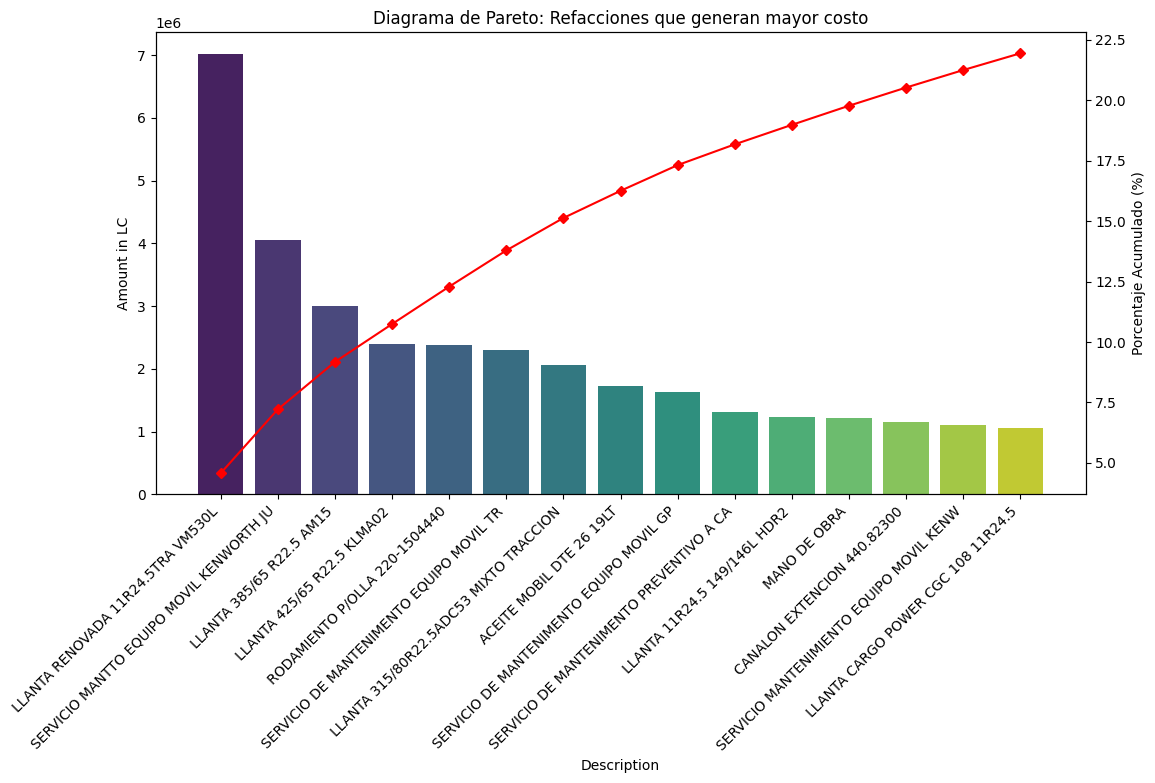

In [24]:
# Agrupamos por material y sumamos el costo total (Amount in LC)
pareto_df = data_refacciones.groupby('Description')['Amount in LC'].sum().sort_values(ascending=False).reset_index()
pareto_df['Cumulative_Percentage'] = 100 * pareto_df['Amount in LC'].cumsum() / pareto_df['Amount in LC'].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para el costo individual
sns.barplot(x='Description', y='Amount in LC', data=pareto_df.head(15), ax=ax1, palette='viridis')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Línea para el porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(pareto_df['Description'].head(15), pareto_df['Cumulative_Percentage'].head(15), color='red', marker='D', ms=5)
ax2.set_ylabel('Porcentaje Acumulado (%)')

plt.title('Diagrama de Pareto: Refacciones que generan mayor costo')
plt.show()

In [25]:
    # --- 1. CONSOLIDACIÓN DE DATOS ---
# Unimos las refacciones con las órdenes y los equipos para rastrear el origen (TIPO)
df_consolidado = pd.merge(
    data_refacciones, 
    data_ordenes[['Order', 'Equipment', 'Total act.costs']], 
    on='Order', 
    how='left'
)

df_consolidado = pd.merge(
    df_consolidado, 
    data_equipos[['EQUIPO', 'MARCA', 'TIPO']], 
    left_on='Equipment', 
    right_on='EQUIPO', 
    how='left'
)

# --- 2. RESUMEN POR MATERIAL (CATÁLOGO ÚNICO) ---
analisis_refacciones = df_consolidado.groupby(['Material', 'Description']).agg({
    'Order': 'count',           # Frecuencia de falla
    'Quantity': 'sum',          # Consumo total de piezas
    'Amount in LC': 'mean',     # Costo promedio unitario
    'Equipment': 'nunique',     # Impacto en flota (cuántos camiones la usan)
    'TIPO': lambda x: x.mode()[0] if not x.mode().empty else 'AMERICANO' 
}).rename(columns={
    'Order': 'Movimientos_Históricos', 
    'Amount in LC': 'costo_unitario',
    'Equipment': 'equipos_afectados'
}).reset_index()

# --- 3. LÓGICA DE PROTECCIÓN LOGÍSTICA (TIEMPOS REALES GCC) ---
# Tiempos de entrega (Lead Time) definidos por el usuario
LT_AMER_EURO = 3  # 3 días hábiles
LT_CHINA = 15     # 15 días hábiles

def calcular_niveles_reales(row):
    # Consumo diario basado en el historial anual
    demanda_diaria = row['Quantity'] / 365
    
    if row['TIPO'] == 'CHINO':
        # ESTRATEGIA CHINA (15 días)
        # Stock Mínimo: Cubre los 15 días + 5 días de seguridad (Total 20 días)
        minimo = np.ceil(demanda_diaria * (LT_CHINA + 5)) 
        # Stock Meta: 45 días (Mes y medio) para evitar pedidos constantes
        meta = np.ceil(demanda_diaria * 45)             
        riesgo = "🟡 MEDIO (IMPORTACIÓN 15D)"
    else:
        # ESTRATEGIA AMERICANO / EUROPEO (3 días)
        # Stock Mínimo: Cubre los 3 días + 2 días de colchón (Total 5 días)
        minimo = np.ceil(demanda_diaria * (LT_AMER_EURO + 2))
        # Stock Meta: 15 días (Suficiente por la alta disponibilidad)
        meta = np.ceil(demanda_diaria * 15)              
        riesgo = "🟢 BAJO (LOCAL/EU 3D)"
        
    # Validamos que si hay consumo, el stock mínimo sea al menos 1 pieza
    return pd.Series([max(minimo, 1), max(meta, minimo, 1), riesgo])

# Aplicamos los cálculos de niveles
analisis_refacciones[['Stock_Minimo', 'Stock_Meta_Sugerido', 'Estatus_Logistico']] = \
    analisis_refacciones.apply(calcular_niveles_reales, axis=1)

# --- 4. CRITICIDAD Y ORDENAMIENTO ---
analisis_refacciones['costo_unitario'] = analisis_refacciones['costo_unitario'].fillna(0)
# Score: A mayor movimiento y más equipos afectados, mayor importancia en el reporte
analisis_refacciones['score_criticidad'] = (
    analisis_refacciones['Movimientos_Históricos'] * analisis_refacciones['equipos_afectados'] * analisis_refacciones['costo_unitario']
)

# Columnas finales para Eduardo
columnas_finales = [
    'Description', 'TIPO', 'Estatus_Logistico', 
    'Movimientos_Históricos', 'Stock_Minimo', 'Stock_Meta_Sugerido'
]

resultado_final = analisis_refacciones[columnas_finales].sort_values(
    by=['Estatus_Logistico', 'Movimientos_Históricos'], 
    ascending=[True, False] 
)

# --- 5. VISUALIZACIÓN Y SALIDA ---
# Aplicamos formato visual para identificar materiales de alto movimiento
display(resultado_final.head(10).style.format({
    'Stock_Minimo': '{:.0f}',
    'Stock_Meta_Sugerido': '{:.0f}'
}).background_gradient(subset=['Movimientos_Históricos'], cmap='YlOrRd'))

# Generamos el Excel estratégico
nombre_archivo = "Abastecimiento_Optimizado_GCC.xlsx"
resultado_final.to_excel(nombre_archivo, index=False)
print(f"✅ Reporte generado exitosamente como: {nombre_archivo}")

,Description,TIPO,Estatus_Logistico,Movimientos_Históricos,Stock_Minimo,Stock_Meta_Sugerido
798,UREA COMPASS BLUE CC36057MSP,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),941,69,154
370,LLANTA 315/80R22.5ADC53 MIXTO TRACCION,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),289,20,45
380,FILTRO ACEITE 200V05504-0122,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),134,8,17
797,ACEITE SINOTRUK RLCM 10W40,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),134,90,203
390,FILTRO AIRE WG9X25190061/1,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),125,7,16
383,FILTRO UREA 202V27120-0066,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),124,7,16
389,FILTRO AIRE WG9X25190061/2,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),122,7,15
382,FILTRO COMBUSTIBLE WG9925550212,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),113,6,14
385,FILTRO AIRE 711W61900-0051/5.,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),113,7,14
381,FILTRO COMBUSTIBLE 201V12503-0062,CHINO,🟡 MEDIO (IMPORTACIÓN 15D),111,7,14


✅ Reporte generado exitosamente como: Abastecimiento_Optimizado_GCC.xlsx


In [26]:
# Unimos las tablas necesarias
df_completo = pd.merge(data_refacciones, data_ordenes[['Order', 'Equipment']], on='Order')
df_completo = pd.merge(df_completo, data_equipos[['EQUIPO', 'TIPO', 'MODELO']], left_on='Equipment', right_on='EQUIPO')

# Filtramos: Solo filas donde la descripción contenga "FILTRO" y el tipo sea "CHINO"
# Usamos .str.contains para atrapar 'FILTRO ACEITE', 'FILTRO AIRE', etc.
filtros_chinos = df_completo[
    (df_completo['Description'].str.contains('FILTRO', case=False)) & 
    (df_completo['TIPO'] == 'CHINO')
]

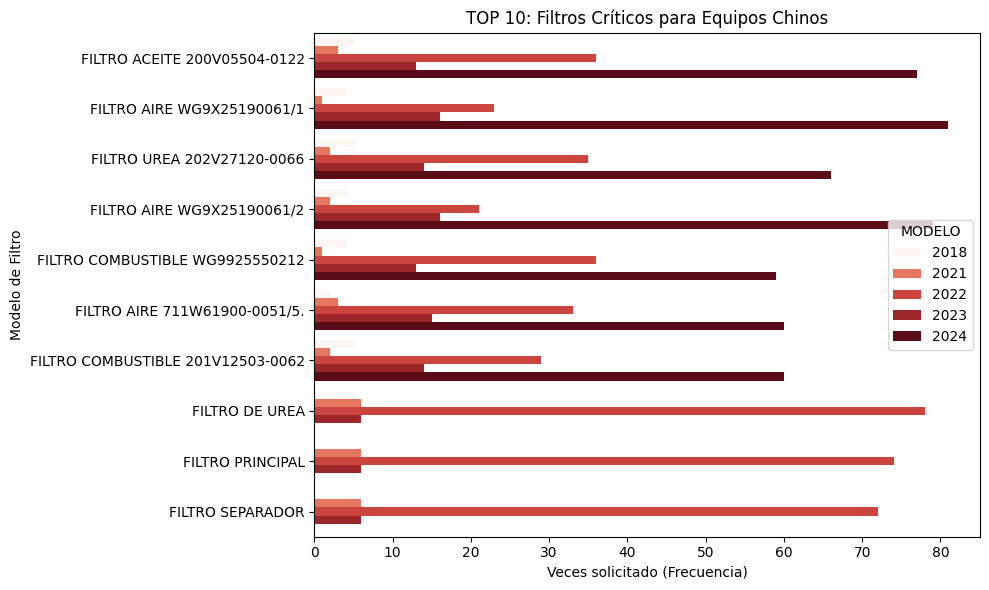

In [27]:
# 1. Filtramos solo los filtros chinos y quitamos los que casi no se usan
filtros_chinos = df_completo[
    (df_completo['Description'].str.contains('FILTRO', case=False)) & 
    (df_completo['TIPO'] == 'CHINO')
]

# 2. Solo tomamos los 10 filtros que más se han pedido
top_filtros_chinos = filtros_chinos['Description'].value_counts().nlargest(10).index
df_plot = filtros_chinos[filtros_chinos['Description'].isin(top_filtros_chinos)]

# 3. Gráfica limpia
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_plot, 
    y='Description', 
    hue='MODELO', 
    order=top_filtros_chinos,
    palette='Reds'
)
plt.title('TOP 10: Filtros Críticos para Equipos Chinos')
plt.xlabel('Veces solicitado (Frecuencia)')
plt.ylabel('Modelo de Filtro')
plt.tight_layout() # Esto evita que se corten las etiquetas
plt.show()

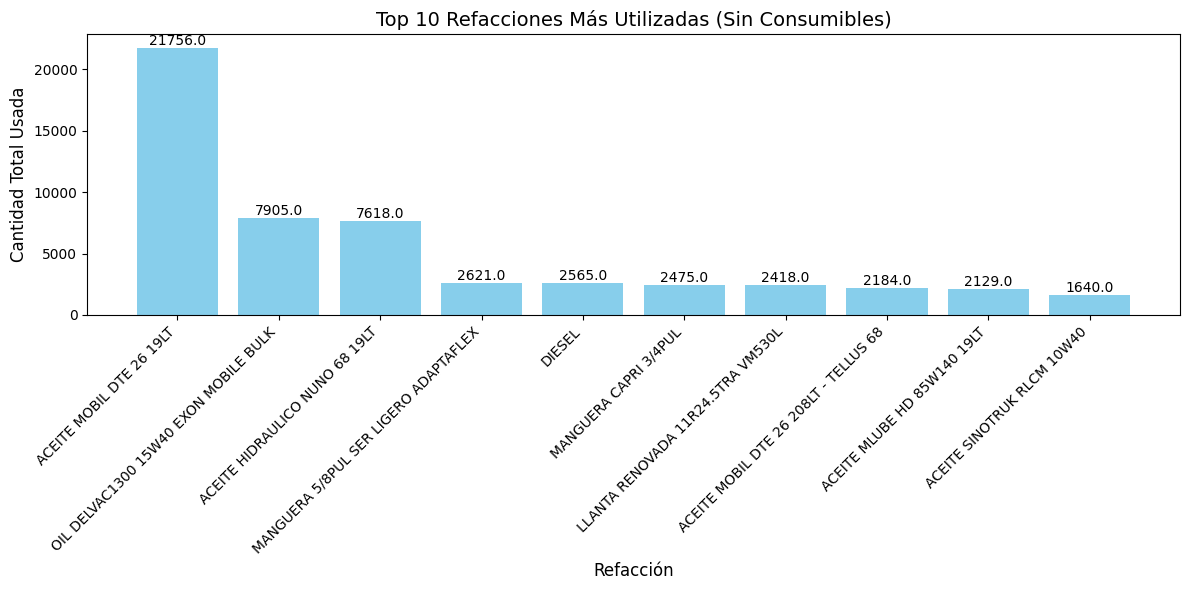

In [28]:
# 1. Agrupar por descripción y sumar la cantidad total
top_10_refacciones = (
    data_refacciones
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 2. Crear la visualización
plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_refacciones['Description'], top_10_refacciones['Quantity'], color='skyblue')

# 3. Estética de la gráfica
plt.title('Top 10 Refacciones Más Utilizadas (Sin Consumibles)', fontsize=14)
plt.xlabel('Refacción', fontsize=12)
plt.ylabel('Cantidad Total Usada', fontsize=12)
plt.xticks(rotation=45, ha='right') 

# Añadir etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()